In [22]:
# Set up plotting in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font',size=18)
rc('lines',linewidth=3)
rc('axes',linewidth=3)

In [3]:
# Python imports
import numpy as np
from numpy import pi
import datetime
from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from scipy.interpolate import RectBivariateSpline, SmoothBivariateSpline, bisplrep, bisplev, interp2d
from scipy.optimize import brentq
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import norm
from collections import OrderedDict

# PyNitride simulation imports
from pynitride.mesh import Mesh, MaterialBlock, UniformLayer
from pynitride.material import AlGaN, Insulator
from pynitride.solvers import PoissonSolver, Equilibrium, SelfConsistentLoop, Linear_Fermi
from pynitride.strain import Pseudomorphic
from pynitride.thermal import ConstantT
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP
from pynitride.visual import sublog, log
from pynitride.paramdb import pmdb
from pynitride.phonons import ElasticContinuum

# Constants and units (import from PyNitride so whole notebook is in consistent units system)
# To get a value in SI or other units in any sort, use to_unit
from pynitride.paramdb import nm,cm, k as kb, eV, hbar, m_e
T=300
from pynitride.paramdb import to_unit

# Definitions

In [12]:
# Store all simulation results in a dict
sims={}

# Dict and name of most recently run simulation
sim=None
simname=None


def runsim(name,struct,qpoints,qmax,neig,qshift,force=False,bctop=.0001,bcbottom=.0001,uniformmesh=False):
    """ Runs a simulation if it has not already been run.  Regardless, sets the global sim/simname as given.
    
    Args:
        name (str) - name of the simulation that will used in the global sims dict
        straincond (dict) - a straincond argument which will be given to the Pseudomorphic solver
        sbh (float) - a surface barrer potential [eV] to use
        force (bool) - whether to run the simulation again even if it exists in the dictionary
    """
    
    # Check against the global sims dict.
    # If a simulation by this name already exists, no need to rerun (unless forced).
    global sim, simname
    simname=name
    if name in sims and not force:
        sim=sims[name]
        print("Already ran")
        return
    
    # Otherwise, let's run
    starttime=datetime.datetime.now()
    sbh=1*eV
    with sublog("Solving "+str(starttime)):
        sim=sims[name]={}

        ## Define mesh
        sim['m']=m=Mesh(
            [MaterialBlock("epi",AlGaN(),
                [UniformLayer(str(i),t,x=(1 if mat=='AlN' else 0)) for i,(mat,t) in enumerate(struct)])],
            max_dz=.5*nm,
            refinements=[["{}/{}".format(i,i+1),.05*nm,1.3] for i in range(len(struct)-1)]\
                +[[0,.05*nm,1.3],[sum(t for mat,t in struct),.05*nm,1.3]],
            boundary=[sbh,'thick'], uniform=uniformmesh
        )
        
        # Constant temperature
        ConstantT(m,T=T)
        
        ## Define solvers 
        sim['ec']=ec=ElasticContinuum(m,num_eigenvalues=neig,qmax=qmax,num_qpoints=qpoints,qshift=qshift,bctop=bctop,bcbottom=bcbottom)
        
        
        ## Initialize the mesh and all solvers
        m.initialize()
        #m.C11[:]=0;m.C12[:]=0;m.C13[:]=0;m.C33[:]=0;m.C44[:]=0;
        for solver in [ec]:
            solver.initialize()

        ec.solve(debugmode=True)
        
        # Make a shorthand list of properties for convenience
        sim['res']={}
    endtime=datetime.datetime.now()
    log("Finished solve at "+str(endtime)+" took "+str(endtime-starttime))

In [5]:
from pynitride.mesh import PointFunction

In [6]:
def sort_modes(en,vec,criteria):
    m=vec.mesh
    criteria+=[lambda v: True]
    bins=[[[],[]] for c in criteria]
    for iq in range(en.shape[0]):
        for be,bv in bins:
            be+=[[]];bv+=[[]] 
        for eig in range(en.shape[1]):
            for ic,c in enumerate(criteria):
                if c(vec[iq,eig]):
                    bins[ic][0][iq]+=[en[iq,eig]]
                    bins[ic][1][iq]+=[vec[iq,eig]]
                    break
    for c in range(len(criteria)):
        countc=min(len(bins[c][0][iq]) for iq in range(len(en)))
        print("Criteria #",c," has ",countc," complete modes.")
        bins[c][0]=np.array([np.array(bins[c][0][iq][:countc]) for iq in range(len(en))])
        bins[c][1]=PointFunction(m,np.array([np.array(bins[c][1][iq][:countc]) for iq in range(len(en))],dtype='complex'),dtype='complex')
    return bins

In [7]:
def isas(v,plot=False):
    """ For use with sort_modes, is this mode AS (as opposed to SA).
    
    Assumes the answer is one of those two options...
    """
    def doplot():
        plt.figure(figsize=(9,3))
        plt.subplot(131)
        plt.plot(m._zp,v[0].real,'.-')
        plt.plot(m._zp,v[0].imag)
        plt.axhline(0,color='k')
        plt.axvline(3,color='k')
        plt.autoscale(enable=True, axis='x', tight=True)
        plt.grid(True,axis='y')
        plt.subplot(132)
        plt.plot(m._zp,v[1].real)
        plt.plot(m._zp,v[1].imag)
        plt.axhline(0,color='k')
        plt.axvline(3,color='k')
        plt.autoscale(enable=True, axis='x', tight=True)
        plt.grid(True,axis='y')
        plt.subplot(133)
        plt.plot(m._zp,v[2].real)
        plt.plot(m._zp,v[2].imag)
        plt.axhline(0,color='k')
        plt.axvline(3,color='k')
        plt.autoscale(enable=True, axis='x', tight=True)
        plt.grid(True,axis='y')
        plt.tight_layout()
        
    i=m.indexp((m._zp[-1]+m._zp[0])/2)
    if (m.density.tpf()*np.abs(v[0])**2).integrate(definite=True)>1e-7:
        dec= v[0,0]/v[0,-1]<0
    elif (m.density.tpf()*np.abs(v[2])**2).integrate(definite=True)>1e-7:
        dec= v[2,0]/v[2,-1]>0
    else:
        doplot()
        raise Exception("hai")
        
    #if (np.trapz(np.abs(v[1,:])**2,m._zp)>.95): return
    
    if plot:
        doplot()
        if dec:
            plt.gcf().axes[0].set_title("x is A")
            plt.gcf().axes[1].set_title("y")
            plt.gcf().axes[2].set_title("z is S")
        else:
            plt.gcf().axes[0].set_title("x is S")
            plt.gcf().axes[1].set_title("y")
            plt.gcf().axes[2].set_title("z is A")
    return dec

# pFET

In [108]:
runsim("pFET",[('GaN',10*nm),('AlN',100*nm)],qpoints=100,qmax=2,neig=250,qshift=.01,force=True,
      bctop=1e-8,bcbottom=1e8)
m=sim['m']
ec=sim['ec']
(y_en,y_vec),(xz_en,xz_vec)=sort_modes(ec._en,ec._vecs, [lambda v:\
    ((m.density.tpf()*np.abs(v[1,:])**2).integrate(definite=True)>.95)])

Solving 2018-12-03 19:49:45.457677
  Assembling EC matrices ...
  Done assembly.
Finished solve at 2018-12-03 19:58:01.710940 took 0:08:16.253263
Criteria # 0  has  99  complete modes.
Criteria # 1  has  122  complete modes.


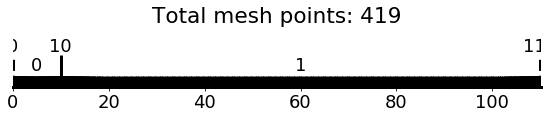

In [103]:
m.plot_mesh()

In [104]:
v1=5965.13/to_unit(1,"m/s")
v1

0.00596513

Text(1.2,2.5,'Discrete modes')

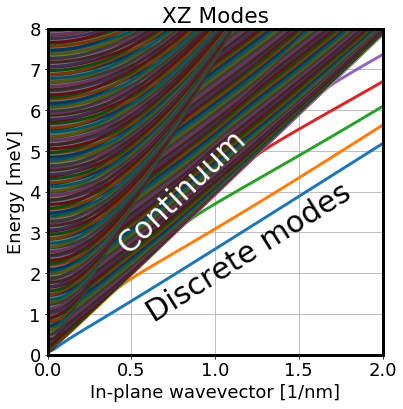

In [264]:
plt.figure(figsize=(6,6))
plt.plot(ec._q,xz_en*1e3)
#plt.plot(ec._q, y_en*1e3,color='g')
plt.fill_betweenx(2*hbar*v1*ec._q/1e-3,2*ec._q,linewidth=.5,color='k',alpha=.55,zorder=10)
plt.xlim(0,2)
plt.ylim(0,8)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")
plt.title("XZ Modes")

plt.grid(True)

#plt.gcf().transFigure.inverted().transform(plt.gca().transData.transform([1,hbar*v1*ec._q/1e3]))
plt.draw()
rot=np.arctan2(*reversed(plt.gca().transData.transform([1,hbar*v1*1/nm*1e3])-plt.gca().transData.transform([0,0])))
plt.text(.8,4,"Continuum",color='w',rotation=rot*180/np.pi,ha='center',va='center',fontsize=30,zorder=20)
rot=np.arctan2(*reversed(plt.gca().transData.transform([ec._q[-1],xz_en[-1,0]*1e3])-plt.gca().transData.transform([0,0])))
plt.text(1.2,2.5,"Discrete modes",rotation=rot*180/np.pi,color='k',ha='center',va='center',fontsize=30)

In [117]:
v2=6302.69/to_unit(1,"m/s")
v2

0.00630269

Text(1.2,2.8,'Discrete modes')

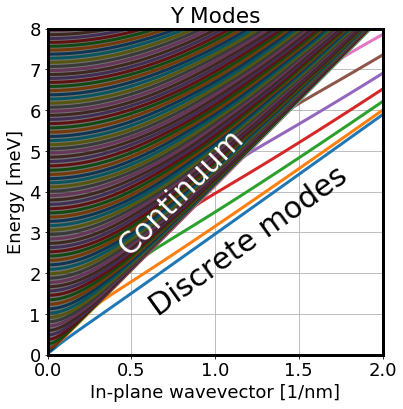

In [121]:
plt.figure(figsize=(6,6))
#plt.plot(ec._q,xz_en*1e3)
plt.plot(ec._q, y_en*1e3)
plt.fill_betweenx(2*hbar*v2*ec._q/1e-3,2*ec._q,linewidth=.5,color='k',alpha=.55,zorder=10)
plt.xlim(0,2)
plt.ylim(0,8)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")
plt.title("Y Modes")

plt.grid(True)

#plt.gcf().transFigure.inverted().transform(plt.gca().transData.transform([1,hbar*v1*ec._q/1e3]))
plt.draw()
rot=np.arctan2(*reversed(plt.gca().transData.transform([1,hbar*v2*1/nm*1e3])-plt.gca().transData.transform([0,0])))
plt.text(.8,4,"Continuum",color='w',rotation=rot*180/np.pi,ha='center',va='center',fontsize=30,zorder=20)
rot=np.arctan2(*reversed(plt.gca().transData.transform([ec._q[-1],y_en[-1,0]*1e3])-plt.gca().transData.transform([0,0])))
plt.text(1.2,2.8,"Discrete modes",rotation=rot*180/np.pi,color='k',ha='center',va='center',fontsize=30)

In [269]:
def showme(v):
    plt.figure(figsize=(4,8))
    plt.plot(v[0,:].real,m._zp,'b',label='Re{X}')
    plt.plot(v[0,:].imag,m._zp,'b--',label='Im{X}')
    #plt.plot(v[1,:].real,m._zp,'g')
    #plt.plot(v[1,:].imag,m._zp,'g--')
    plt.plot(v[2,:].real,m._zp,'r',label='Re{Z}')
    plt.plot(v[2,:].imag,m._zp,'r--',label='Im{Z}')
    #plt.axhline(m._layers[0].thickness,color='k',linestyle='--')
    plt.ylim(m._zp[-1],0)
    plt.xticks([])
    plt.gca().spines['left'].set_position('zero')
    plt.yticks([])
    plt.gca().spines['right'].set_color(None)
    xlim=plt.xlim()
    plt.fill_between([-10,10],[m._layers[0].thickness]*2,color='b',alpha=.1)
    plt.fill_between([-10,10],[m._layers[0].thickness]*2,[m._zp[-1]]*2,color='g',alpha=.1)
    plt.xlim(xlim)
    plt.legend(loc='lower right')

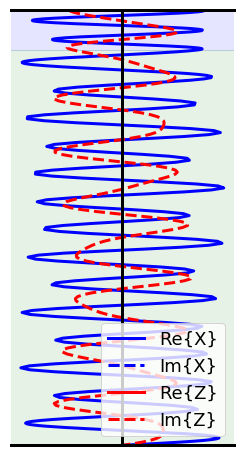

In [270]:
i=8
#print(ec._q[i],xz_en[i,0]*1e3)
showme(xz_vec[i,50]/xz_vec[i,50][0,0])

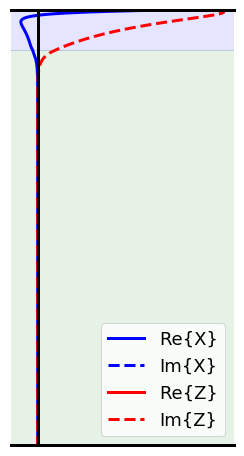

In [271]:
i=50
showme(xz_vec[i,0]/xz_vec[i,0][0,0])

4.4630369914433681

Text(0,0.5,'Group velocity [$10^5$cm/s]')

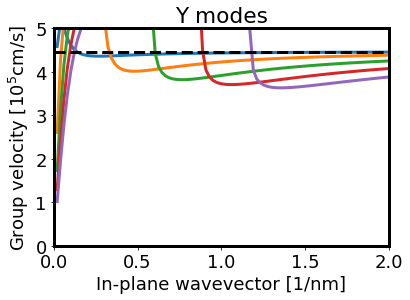

In [275]:
plt.title("Y modes")
plt.plot((ec._q[1:]+ec._q[:-1])/2,to_unit((np.diff(y_en[:,:5],axis=0).T/hbar/np.diff(ec._q)).T,"1e5 cm/s"))
plt.axhline(to_unit(np.sqrt((pmdb['GaN.stiffness.C11']-pmdb['GaN.stiffness.C12'])/(2*pmdb['GaN.density'])),"1e5 cm/s"),
    linestyle='--',color='k')
plt.ylim(0,5)
plt.xlim(0,2)
plt.xlabel("In-plane wavevector [1/nm]")
plt.ylabel("Group velocity [$10^5$cm/s]")

Text(0,0.5,'Group velocity [$10^5$cm/s]')

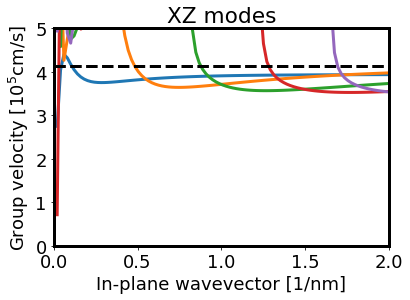

In [279]:
plt.title("XZ modes")
plt.plot((ec._q[1:]+ec._q[:-1])/2,to_unit((np.diff(xz_en[:,:5],axis=0).T/hbar/np.diff(ec._q)).T,"1e5 cm/s"))
plt.axhline(to_unit(np.sqrt((pmdb['GaN.stiffness.C44'])/(pmdb['GaN.density'])),"1e5 cm/s"),
    linestyle='--',color='k')
plt.axhline(to_unit(np.sqrt((pmdb['GaN.stiffness.C44'])/(pmdb['GaN.density'])),"1e5 cm/s"),
    linestyle='--',color='k')
plt.ylim(0,5)
plt.xlim(0,2)
plt.xlabel("In-plane wavevector [1/nm]")
plt.ylabel("Group velocity [$10^5$cm/s]")

In [60]:
def islocalized(v,plot=False):    
    inreg=np.sum((m.density.tpf()*np.abs(v)**2).integrate(definite=False)[:,m.indexp(10)])
    tot=np.sum((m.density.tpf()*np.abs(v)**2).integrate(definite=True))
    
    if plot:
        plt.plot(m._zp,np.sum(m.density.tpf()*np.abs(v)**2,axis=0))
        print(inreg/tot)
    return float(inreg/tot)>.1

10

In [178]:
from matplotlib.patches import Rectangle

0.9292899755854129


True

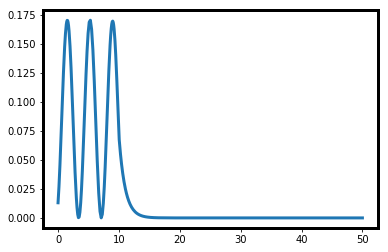

In [106]:
islocalized(ec._vecs[50,4],plot=True)

In [78]:
(l_en,l_vec),(b_en,b_vec)=sort_modes(ec._en,ec._vecs, [islocalized])

(yl_en,yl_vec),(xzl_en,xzl_vec)=sort_modes(l_en,l_vec, [lambda v:\
    ((np.abs(v[1,:])**2).integrate(definite=True)>.6)])

Criteria # 0  has  63  complete modes.
Criteria # 1  has  21  complete modes.
Criteria # 0  has  22  complete modes.
Criteria # 1  has  35  complete modes.


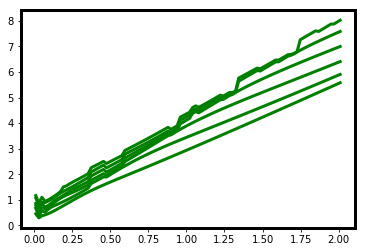

In [81]:
#plt.plot(ec._q, l_en[:,:6]*1e3,color='k')
#plt.plot(ec._q, yl_en[:,:6]*1e3,color='b')
plt.plot(ec._q, xzl_en[:,:6]*1e3,color='g')

# GaN Slab

In [24]:
runsim("GaN slab",struct=[('GaN',3*nm),('GaN',3*nm)],qpoints=80,qmax=6.28,neig=40,qshift=.05,force=True,
      bctop=1e-8,bcbottom=1e-8,uniformmesh=True)
m=sim['m']
ec=sim['ec']
(y_en,y_vec),(xz_en,xz_vec)=sort_modes(ec._en,ec._vecs, [lambda v:\
    ((m.density.tpf()*np.abs(v[1,:])**2).integrate(definite=True)>.95)])
(as_en,as_vec),(sa_en,sa_vec)=sort_modes(xz_en,xz_vec, [lambda v:\
    isas(v)])

Solving 2018-11-29 13:17:36.952887
  Assembling EC matrices ...
  Done assembly.
Finished solve at 2018-11-29 13:17:39.414198 took 0:00:02.461311
Criteria # 0  has  16  complete modes.
Criteria # 1  has  20  complete modes.
Criteria # 0  has  9  complete modes.
Criteria # 1  has  8  complete modes.


In [17]:
ec._vecs.shape

(100, 100, 3, 271)

In [11]:
from numpy.linalg import cond

In [12]:
cond(ec._H[11].todense())

501.6350199489043

In [13]:
cond(ec._H[11].todense())

501.6350199489043

In [14]:
m._zp.shape

(121,)

Compare with Fig 2(a)


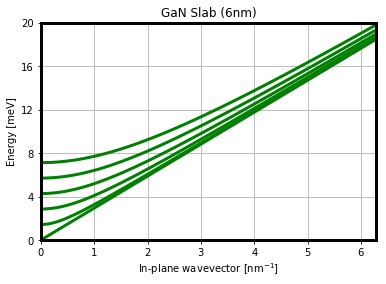

In [25]:
#plt.plot(ec._q,xz_en*1e3,color='b')
plt.plot(ec._q, y_en[:,:6]*1e3,color='g')
plt.xlim(0,6.28)
plt.ylim(0)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [nm$^{-1}$]")
plt.ylim(0,20)
plt.yticks([0,4,8,12,16,20])
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
plt.title("GaN Slab (6nm)")
plt.grid(True)
print("Compare with Fig 2(a)")

True

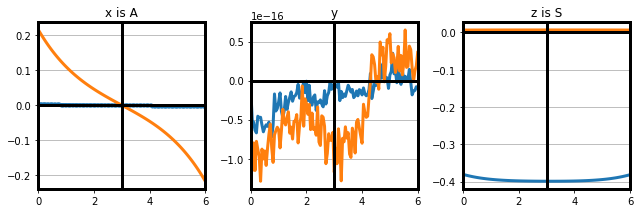

In [16]:
isas(xz_vec[1,0],plot=True)

In [17]:
list(enumerate(ec._q))

[(0, 0.029999999999999999),
 (1, 0.36052631578947369),
 (2, 0.69105263157894747),
 (3, 1.0215789473684211),
 (4, 1.3521052631578949),
 (5, 1.6826315789473687),
 (6, 2.013157894736842),
 (7, 2.343684210526316),
 (8, 2.6742105263157896),
 (9, 3.0047368421052632),
 (10, 3.3352631578947372),
 (11, 3.6657894736842107),
 (12, 3.9963157894736843),
 (13, 4.3268421052631583),
 (14, 4.6573684210526327),
 (15, 4.9878947368421063),
 (16, 5.3184210526315798),
 (17, 5.6489473684210534),
 (18, 5.9794736842105269),
 (19, 6.3100000000000005)]

In [18]:
ec._H[11]

<363x363 sparse matrix of type '<class 'numpy.complex128'>'
	with 3249 stored elements in Compressed Sparse Column format>

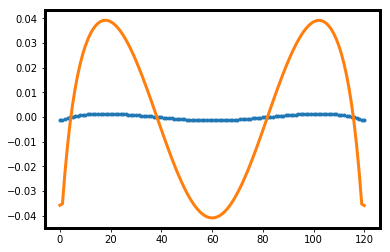

In [19]:
plt.plot(ec._eigenvectorsH[11][0::3,6].real,'.')
plt.plot(ec._eigenvectorsH[11][0::3,6].imag)

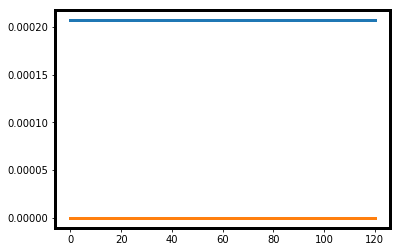

In [20]:
plt.plot(((ec._H[11]*ec._eigenvectorsH[11][:,0])[0::3]/ec._eigenvectorsH[11][0::3,0]).real)
plt.plot(((ec._H[11]*ec._eigenvectorsH[11][:,0])[0::3]/ec._eigenvectorsH[11][0::3,0]).imag)

In [21]:
xz_vec[11,0].shape

(3, 121)

Compare with Fig 4(d)


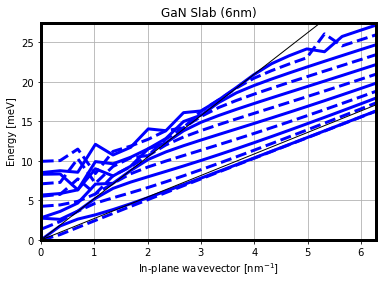

In [22]:
plt.plot(ec._q,sa_en[:,:6]*1e3,'b-')
plt.plot(ec._q,as_en[:,:6]*1e3,'b--')
plt.plot(ec._q,hbar*np.sqrt(m.C44[0]/m.density[0])*ec._q*1e3,'k',linewidth=1)
plt.plot(ec._q,hbar*np.sqrt(m.C11[0]/m.density[0])*ec._q*1e3,'k',linewidth=1)

#plt.plot(ec._q,xz_en[:,:12]*1e3,color='k')
#plt.plot(ec._q, y_en[:,:6]*1e3,color='g')
plt.xlim(0,6.28)
plt.ylim(0)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [nm$^{-1}$]")
plt.yticks(np.linspace(0,25,6))
plt.ylim(0,27.5)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
plt.title("GaN Slab (6nm)")
plt.grid(True)
print("Compare with Fig 4(d)")

Compare with Fig 4(d)


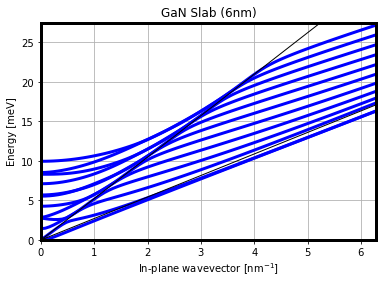

In [71]:
plt.plot(ec._q,xz_en[:,:12]*1e3,'b-')
plt.plot(ec._q,hbar*np.sqrt(m.C44[0]/m.density[0])*ec._q*1e3,'k',linewidth=1)
plt.plot(ec._q,hbar*np.sqrt(m.C11[0]/m.density[0])*ec._q*1e3,'k',linewidth=1)

#plt.plot(ec._q,xz_en[:,:12]*1e3,color='k')
#plt.plot(ec._q, y_en[:,:6]*1e3,color='g')
plt.xlim(0,6.28)
plt.ylim(0)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [nm$^{-1}$]")
plt.yticks(np.linspace(0,25,6))
plt.ylim(0,27.5)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
plt.title("GaN Slab (6nm)")
plt.grid(True)
print("Compare with Fig 4(d)")

Compare with Fig 4(d)


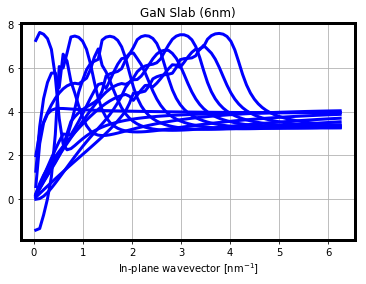

In [73]:
plt.plot((ec._q[1:]+ec._q[:-1])/2,to_unit(np.diff(xz_en[:,:12],axis=0).T/hbar/np.diff(ec._q),"10**3*m/s").T,'b-')
#plt.plot(ec._q,hbar*np.sqrt(m.C44[0]/m.density[0])*ec._q*1e3,'k',linewidth=1)
#plt.plot(ec._q,hbar*np.sqrt(m.C11[0]/m.density[0])*ec._q*1e3,'k',linewidth=1)

#plt.plot(ec._q,xz_en[:,:12]*1e3,color='k')
#plt.plot(ec._q, y_en[:,:6]*1e3,color='g')
#plt.xlim(0,.05)
#plt.ylim(0)
#plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [nm$^{-1}$]")
#plt.yticks(np.linspace(0,25,6))
#plt.ylim(0,.1)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
plt.title("GaN Slab (6nm)")
plt.grid(True)
print("Compare with Fig 4(d)")

In [46]:
runsim("GaN slab",struct=[('GaN',3*nm),('GaN',3*nm)],qpoints=20,qmax=.1,neig=40,qshift=.0001,force=True,
      bctop=1e-9,bcbottom=1e-9,uniformmesh=True)
m=sim['m']
ec=sim['ec']
(y_en,y_vec),(xz_en,xz_vec)=sort_modes(ec._en,ec._vecs, [lambda v:\
    ((np.abs(v[1,:])**2).integrate(definite=True)>.95)])
(as_en,as_vec),(sa_en,sa_vec)=sort_modes(xz_en,xz_vec, [lambda v:\
    isas(v)])

Solving 2018-11-20 03:45:50.741252
  Assembling EC matrices ...
  Done assembly.
Finished solve at 2018-11-20 03:45:51.524022 took 0:00:00.782770
Criteria # 0  has  16  complete modes.
Criteria # 1  has  24  complete modes.
Criteria # 0  has  11  complete modes.
Criteria # 1  has  12  complete modes.


Compare with Fig 4(d)


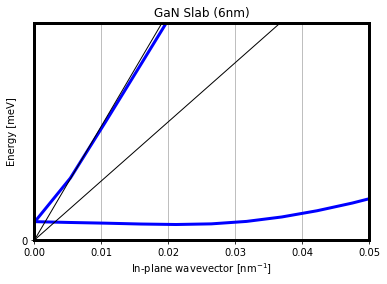

In [47]:
plt.plot(ec._q,xz_en[:,:12]*1e3,'b-')
plt.plot(ec._q,hbar*np.sqrt(m.C44[0]/m.density[0])*ec._q*1e3,'k',linewidth=1)
plt.plot(ec._q,hbar*np.sqrt(m.C11[0]/m.density[0])*ec._q*1e3,'k',linewidth=1)

#plt.plot(ec._q,xz_en[:,:12]*1e3,color='k')
#plt.plot(ec._q, y_en[:,:6]*1e3,color='g')
plt.xlim(0,.05)
plt.ylim(0)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [nm$^{-1}$]")
plt.yticks(np.linspace(0,25,6))
plt.ylim(0,.1)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
plt.title("GaN Slab (6nm)")
plt.grid(True)
print("Compare with Fig 4(d)")

In [57]:
xz_en[0,:12]

array([  8.43516888e-06,   8.57402502e-06,   1.42404779e-03,
         2.77242618e-03,   2.84777565e-03,   4.27103193e-03,
         5.54433884e-03,   5.69356093e-03,   7.11511606e-03,
         8.31530987e-03,   8.53545290e-03,   9.95432771e-03])

1000.0

In [ ]:
ec._H[11]

# 10nm GaN Slab

In [293]:
runsim("10nm GaN slab",struct=[('GaN',5*nm),('GaN',5*nm)],qpoints=80,qmax=6.28,neig=40,qshift=.05,force=True,
      bctop=1e-8,bcbottom=1e-8,uniformmesh=True)
m=sim['m']
ec=sim['ec']
(y_en,y_vec),(xz_en,xz_vec)=sort_modes(ec._en,ec._vecs, [lambda v:\
    ((m.density.tpf()*np.abs(v[1,:])**2).integrate(definite=True)>.95)])
(as_en,as_vec),(sa_en,sa_vec)=sort_modes(xz_en,xz_vec, [lambda v:\
    isas(v)])

Solving 2018-12-10 21:16:21.286439
  Assembling EC matrices ...
  Done assembly.
Finished solve at 2018-12-10 21:16:24.972353 took 0:00:03.685914
Criteria # 0  has  16  complete modes.
Criteria # 1  has  18  complete modes.
Criteria # 0  has  8  complete modes.
Criteria # 1  has  8  complete modes.


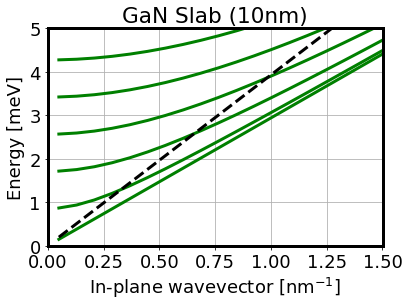

In [307]:
#plt.plot(ec._q,xz_en*1e3,color='b')
plt.plot(ec._q, y_en[:,:6]*1e3,color='g')
plt.xlim(0,1.5)
plt.ylim(0)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [nm$^{-1}$]")
plt.ylim(0,5)
#plt.yticks([0,4,8,12,16,20])
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
plt.xticks(np.linspace(0,1.5,7))
plt.title("GaN Slab (10nm)")
plt.plot(ec._q,1e3*hbar*np.sqrt((pmdb['AlN.stiffness.C44'])/(pmdb['AlN.density']))*ec._q,
    linestyle='--',color='k')
plt.grid(True)

# AlN Slab

In [133]:
runsim("GaN sandwich",struct=[('AlN',2.5*nm),('GaN',1*nm),('AlN',2.5*nm)],qpoints=20,qmax=6.28,neig=35,qshift=.05,force=True)
m=sim['m']
ec=sim['ec']
(y_en,y_vec),(xz_en,xz_vec)=sort_modes(ec._en,ec._vecs, [lambda v:\
    ((np.abs(v[1,:])**2).integrate(definite=True)>.95)])
(as_en,as_vec),(sa_en,sa_vec)=sort_modes(xz_en,xz_vec, [lambda v:\
    isas(v)])

Solving 2018-11-29 11:08:27.653788
  Assembling EC matrices ...
  Done assembly.
Finished solve at 2018-11-29 11:08:28.480824 took 0:00:00.827036
Criteria # 0  has  14  complete modes.
Criteria # 1  has  17  complete modes.
Criteria # 0  has  7  complete modes.
Criteria # 1  has  7  complete modes.


Compare with Fig 2(b)


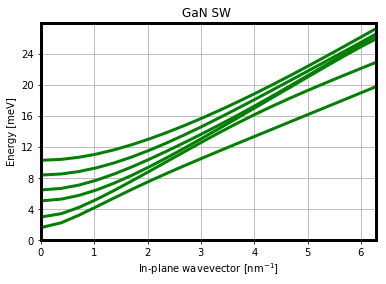

In [134]:
#plt.plot(ec._q,xz_en*1e3,color='b')
plt.plot(ec._q, y_en[:,:6]*1e3,color='g')
plt.xlim(0,6.28)
plt.ylim(0)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [nm$^{-1}$]")
plt.ylim(0,28)
plt.yticks([0,4,8,12,16,20,24])
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
plt.title("GaN SW ")
plt.grid(True)
print("Compare with Fig 2(b)")

Compare with Fig 4(b)


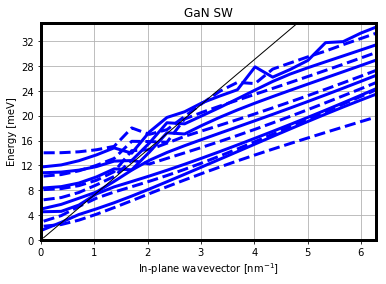

In [9]:
plt.plot(ec._q,sa_en[:,:6]*1e3,'b-')
plt.plot(ec._q,as_en[:,:6]*1e3,'b--')
plt.plot(ec._q,hbar*np.sqrt(m.C11[0]/m.density[0])*ec._q*1e3,'k',linewidth=1)
#plt.plot(ec._q,hbar*np.sqrt(m.C11[200]/m.density[200])*ec._q*1e3+1.5,'k',linewidth=1)

#plt.plot(ec._q,xz_en[:,:12]*1e3,color='k')
#plt.plot(ec._q, y_en[:,:6]*1e3,color='g')
plt.xlim(0,6.28)
plt.ylim(0)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [nm$^{-1}$]")
plt.yticks(np.linspace(0,32,9))
plt.ylim(0,35)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
plt.title("GaN SW")
plt.grid(True)
print("Compare with Fig 4(b)")

# Probably still not hermitian for heterostructure bc of density factor... need to symmetrize that

# Games

In [85]:
from scipy.sparse import diags

In [190]:
n=10000
alpha=10
sam=diags([[2]*n,[-1]*(n-1),[-1]*(n-1)],[0,1,-1],format='lil')#.todense()
sam[0,0]=1+alpha*1/n
sam[-1,-1]=1+alpha*1/n
#sam[int(n/2),int(n/2)]=0
#sam[int(n/4),int(n/4)+1]=0
#sam[int(n/4),int(n/4)-1]=0
sam*=n**2
sam=sam.asformat('csc')
from scipy.sparse.linalg import eigsh
en,ev=eigsh(sam,sigma=0)

In [116]:
en

array([  2.00006665e-04,   9.87000433e+00,   3.94788163e+01,
         8.88268330e+01,   1.57914050e+02,   2.46740459e+02])

In [112]:
en

array([   9.87157854,   39.48631317,   88.84420098,  157.9452371 ,
        246.7894147 ,  355.37672501])

In [191]:
en

array([   6.90576645,   28.17149852,   65.0857064 ,  119.00984681,
        190.98230826,  281.6726778 ])

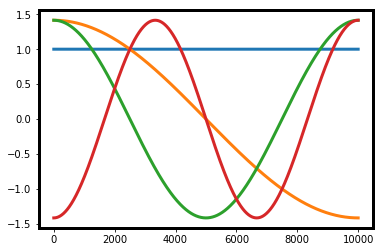

In [117]:
plt.plot(ev[:,0]*np.sqrt(n))
plt.plot(ev[:,1]*np.sqrt(n))
plt.plot(ev[:,2]*np.sqrt(n))
plt.plot(ev[:,3]*np.sqrt(n))

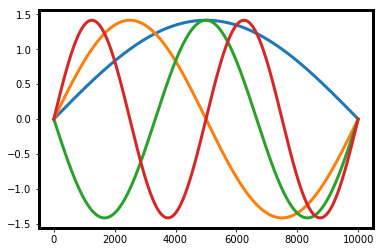

In [113]:
plt.plot(ev[:,0]*np.sqrt(n))
plt.plot(ev[:,1]*np.sqrt(n))
plt.plot(ev[:,2]*np.sqrt(n))
plt.plot(ev[:,3]*np.sqrt(n))

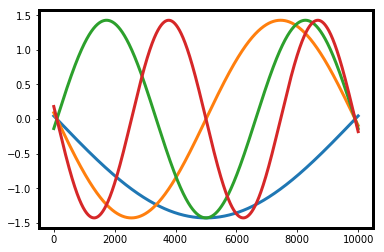

In [182]:
plt.plot(ev[:,0]*np.sqrt(n))
plt.plot(ev[:,1]*np.sqrt(n))
plt.plot(ev[:,2]*np.sqrt(n))
plt.plot(ev[:,3]*np.sqrt(n))